In [1]:
import re
import requests
import string
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import Counter, defaultdict
import tiktoken
import gensim.downloader as api

In [2]:
wiki_glove = api.load("glove-wiki-gigaword-50")
twit_glove = api.load("glove-twitter-50")

[==================================================] 100.0% 199.5/199.5MB downloaded


In [4]:
wiki_glove.vectors.shape, twit_glove.vectors.shape

((400000, 50), (1193514, 50))

Text(0, 0.5, 'Twitter embedding')

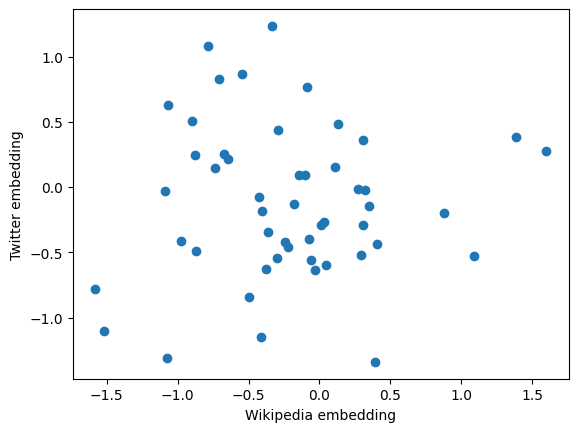

In [ ]:
word = "starship"
plt.scatter(wiki_glove[word], twit_glove[word])
plt.xlabel("Wikipedia embedding")
plt.ylabel("Twitter embedding")
# we can see there is no correlation between both embeddings vector

Text(0.5, 1.0, 'Twitter Cosine Similarity 0.837')

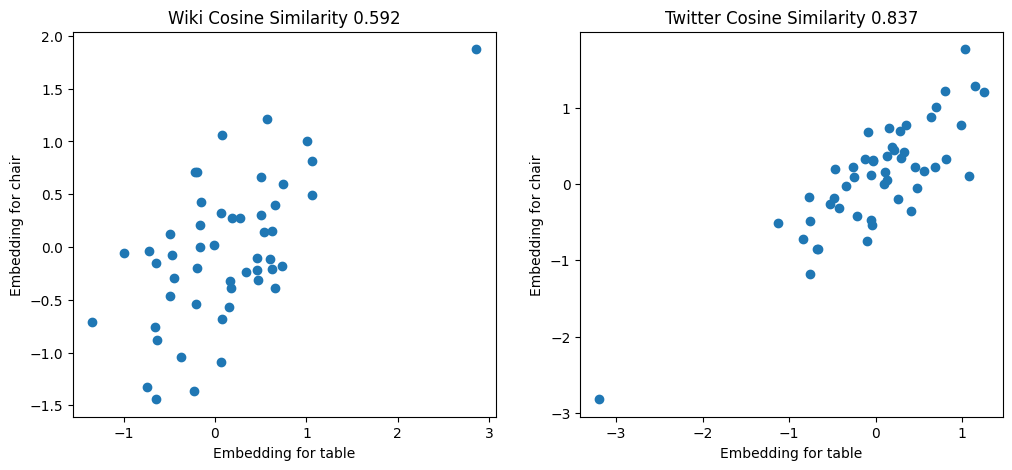

In [22]:
word1 = "table"
word2 = "chair"

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].scatter(wiki_glove[word1], wiki_glove[word2])
axs[0].set_xlabel(f"Embedding for {word1}")
axs[0].set_ylabel(f"Embedding for {word2}")
axs[0].set_title(f"Wiki Cosine Similarity {wiki_glove.similarity(word1, word2):.3f}")

axs[1].scatter(twit_glove[word1], twit_glove[word2])
axs[1].set_xlabel(f"Embedding for {word1}")
axs[1].set_ylabel(f"Embedding for {word2}")
axs[1].set_title(f"Twitter Cosine Similarity {twit_glove.similarity(word1, word2):.3f}")

# even in the last example, both embeddings had different ways of vectorized "table"
# now we can see that both of them keep a strong correlation between chair and table
# event though the strenght of this correlation may change.

In [ ]:
word = "battery"

print(wiki_glove.most_similar(word, topn=5))
print(twit_glove.most_similar(word, topn=5))

# we can see the similarity values are higher in twitter than in wikipedia where it drops to 0.68 quickly, which is consistent with what we have seen
# in the previous example, where the same two words had higher values for twitter model.

[('batteries', 0.8322107195854187), ('rechargeable', 0.7258116602897644), ('lithium-ion', 0.7082582116127014), ('weapon', 0.6928435564041138), ('machine', 0.6787962913513184)]
[('charger', 0.8720738887786865), ('cell', 0.8216446042060852), ('batteries', 0.8167192935943604), ('laptop', 0.8139174580574036), ('batt', 0.8042665719985962)]


In [37]:
sentence = "The quick brown fox jumps over the lazy dog"
df_index = pd.DataFrame()
for i, word in enumerate(sentence.split(" ")):
    df_index.loc[i, "word"] = word.lower()
    df_index.loc[i, "wiki"] = wiki_glove.get_index(word.lower())
    df_index.loc[i, "twit"] = twit_glove.get_index(word.lower())
    
df_index["wiki"] = df_index["wiki"].astype(int)
df_index["twit"] = df_index["twit"].astype(int)
df_index

,word,wiki,twit
0,the,0,13
1,quick,2582,2156
2,brown,1042,1871
3,fox,2106,4000
4,jumps,11070,18014
5,over,74,254
6,the,0,13
7,lazy,16531,2222
8,dog,2926,1317


In [40]:
from itertools import combinations

# 1. Generate all unique pairs from the sentence
# This creates ('the', 'quick'), ('the', 'brown'), ('quick', 'brown'), etc.
word_list = df_index["word"].tolist()
pair_list = list(combinations(word_list, 2))

wiki_sims = []
twit_sims = []
labels = []

# 2. Calculate similarities using the built-in .similarity() method
for w1, w2 in pair_list:
    try:
        # Using the internal cosine similarity
        s_wiki = wiki_glove.similarity(w1, w2)
        s_twit = twit_glove.similarity(w1, w2)
        
        wiki_sims.append(s_wiki)
        twit_sims.append(s_twit)
        labels.append(f"{w1}-{w2}")
    except KeyError:
        # Handle cases where a word might not be in the vocabulary
        continue

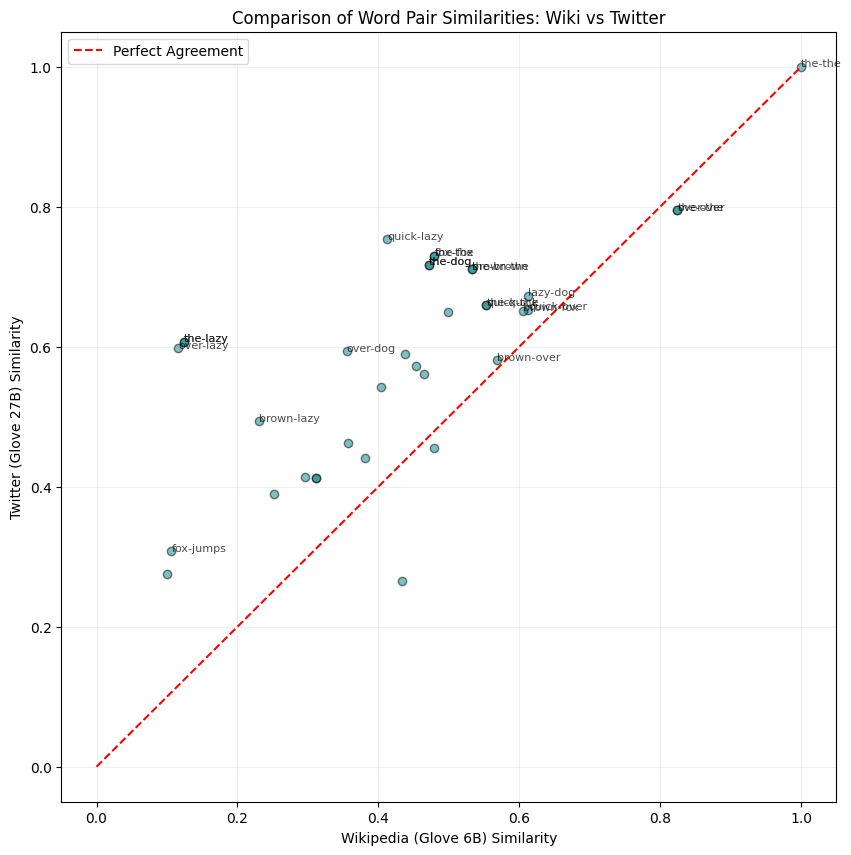

In [ ]:
# 3. Plotting
plt.figure(figsize=(10, 10))
plt.scatter(wiki_sims, twit_sims, alpha=0.5, c='teal', edgecolors='k')

# Add labels for a few interesting ones (to avoid crowding)
# We'll label pairs with high similarity or high discrepancy
for i, label in enumerate(labels):
    if wiki_sims[i] > 0.5 or abs(wiki_sims[i] - twit_sims[i]) > 0.2:
        plt.annotate(label, (wiki_sims[i], twit_sims[i]), fontsize=8, alpha=0.7)

# Reference line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label="Perfect Agreement")

plt.title("Comparison of Word Pair Similarities: Wiki vs Twitter")
plt.xlabel("Wikipedia (Glove 6B) Similarity")
plt.ylabel("Twitter (Glove 27B) Similarity")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# the relation across words depends on the data set in which those embeddings models were trained, since if the relation was the same
# we would say all the points laying over the red dot-line. which reflects that the text structure that we could find is different in wikipedia and twitter.
# we could see again that the points mainly over the line, meaning that twitter seems to have higher correlations between words.